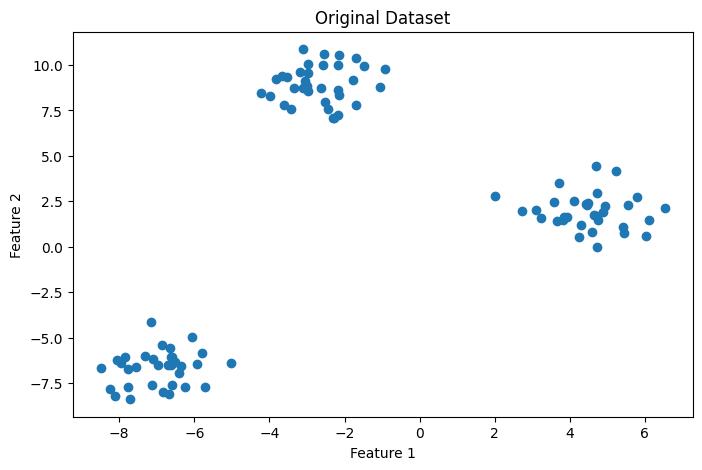

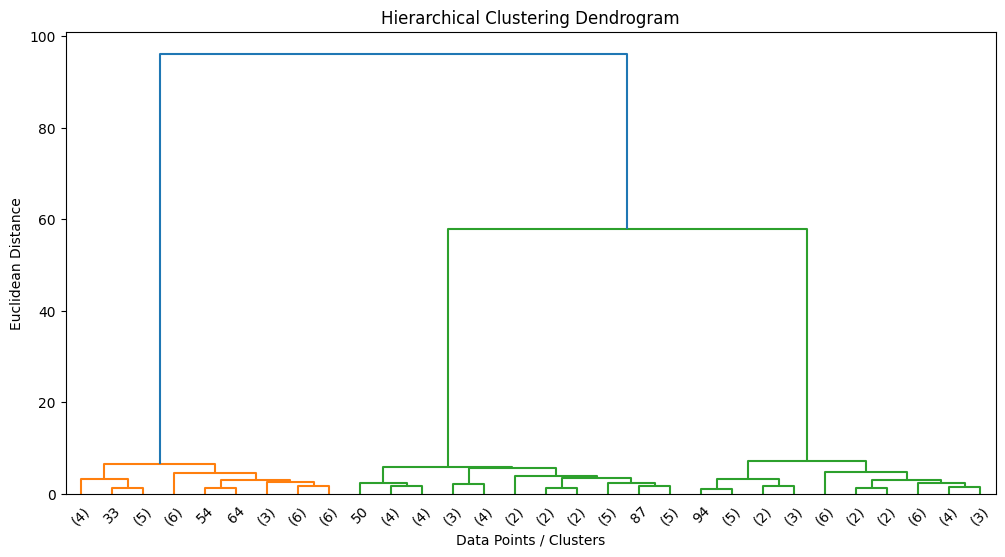

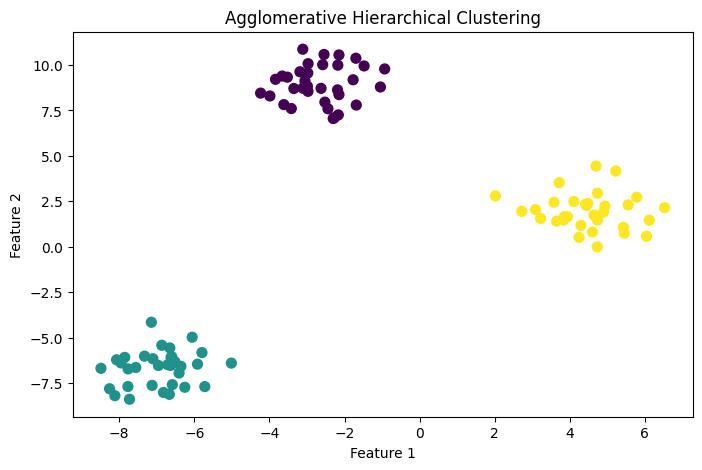

Evaluation Results
-------------------------
Number of Clusters: 3
Silhouette Score: 0.8469881221532085
Cluster 0: 34 data points
Cluster 1: 33 data points
Cluster 2: 33 data points


In [1]:
# ==========================================
# Experiment 3: Hierarchical Clustering
# ==========================================

# 1. Import required libraries
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage


# 2. Generate synthetic dataset
X, y = make_blobs(
    n_samples=100,
    centers=3,
    cluster_std=1.0,
    random_state=42
)


# 3. Visualize original dataset
plt.figure(figsize=(8, 5))

plt.scatter(X[:, 0], X[:, 1])

plt.title("Original Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ==========================================
# 4. Generate Dendrogram
# ==========================================

# Apply Ward linkage
Z = linkage(X, method='ward')

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode='lastp',
    p=30
)

plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Data Points / Clusters")
plt.ylabel("Euclidean Distance")
plt.show()


# ==========================================
# 5. Apply Agglomerative Clustering
# ==========================================

k = 3

hc = AgglomerativeClustering(
    n_clusters=k,
    linkage='ward'
)

labels = hc.fit_predict(X)


# ==========================================
# 6. Visualize Final Clusters
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap='viridis',
    s=50
)

plt.title("Agglomerative Hierarchical Clustering")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()


# ==========================================
# 7. Evaluation
# ==========================================

silhouette = silhouette_score(X, labels)

print("Evaluation Results")
print("-------------------------")
print("Number of Clusters:", k)
print("Silhouette Score:", silhouette)


# ==========================================
# 8. Display Cluster Information
# ==========================================

for i in range(k):
    print(
        f"Cluster {i}: {np.sum(labels == i)} data points"
    )